Import Needed Libraries

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

%matplotlib inline

Import the dataSet

In [16]:
data = pd.read_csv('data/Advertising.csv',index_col=0) # index_col : it assigns 1st column as the index column 

In [18]:
data.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Simple Linear Regression

Start with basics

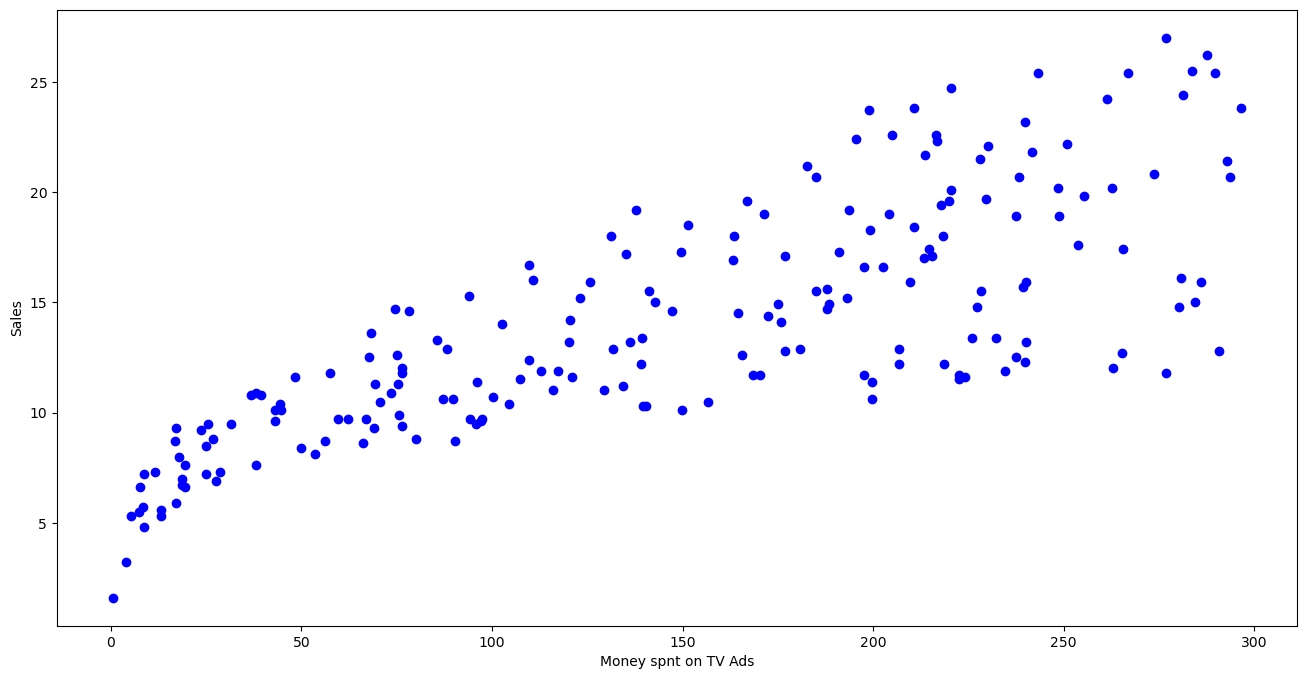

In [21]:
plt.figure(figsize=(16,8))
plt.scatter(data['TV'],data['sales'],c='blue')
plt.xlabel('Money spnt on TV Ads')
plt.ylabel('Sales')
plt.show()

Linear Regression is not the best model for this data, But we are using it for practice purpose only

In [28]:
X = data['TV'].values.reshape(-1,1)
y = data['sales'].values.reshape(-1,1)

# Calling Regression Funtion

reg = LinearRegression()

reg.fit(X,y)

print(f"Linear Model Y : {reg.intercept_[0]} + {reg.coef_[0][0]}*TV")  

# If You notice we have used : reg.intercept_[0] , reg.coef_[0][0] , 
# reg.intercept_[0] : It accessess the 1st array item (1st element in an array). 
# reg.coef_[0][0] : It is used to get the slope of the array element, here we are accessing 2d array element, i.e. 1st row - 1st element. EX : [[0.0475, 0.1885, -0.001]]

Linear Model Y : 7.032593549127694 + 0.04753664043301976*TV


Check the below link for proper understanding

URL : https://chatgpt.com/share/6a29781f-d328-83ec-8a16-d52138edd9a4

Lets plot the graph for the trained model

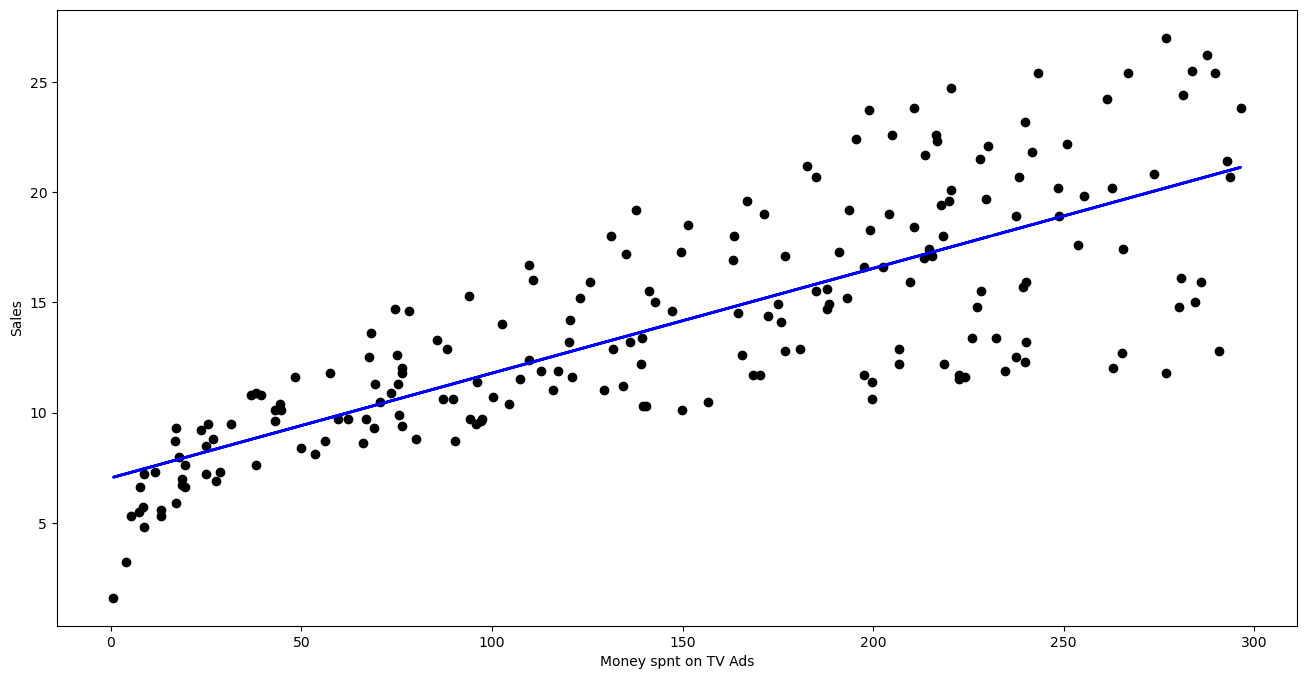

In [35]:
predictions = reg.predict(X)

plt.figure(figsize=(16,8))
plt.scatter(X,y,c='black')
plt.plot(X,predictions,c='blue',linewidth=2)
plt.xlabel('Money spnt on TV Ads')
plt.ylabel('Sales')
plt.show()

Accessing the quality of the model

Check the below link for proper understanding

URL : https://chatgpt.com/s/t_6a297b7cd14c8191b5bf2f52bc26abb1

In [38]:
# Re-asign the X and y Variables

X = data['TV']
y = data['sales']

# Let's fit the model using statsmodel

exog = sm.add_constant(X) # Exoganius variable
est = sm.OLS(y,exog).fit() # Estimator varible, OLS : Oridnary Least Variable

# Summary

print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.47e-42
Time:                        20:24:26   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

## Multiple Linear Regression

Previously we used only one column in simple LR, here we'll be using all the neccessary columns

In [50]:
Xs = data.drop(['sales'],axis=1)  # sales column is not required, as it is the target
y = data['sales'].values.reshape(-1,1)

reg = LinearRegression()
reg.fit(Xs,y)

print(f"Linear Model : \n Y = {reg.intercept_[0]} + {reg.coef_[0][1]}*TV + {reg.coef_[0][1]}*Radio + {reg.coef_[0][2]}*NewsPaper ")

Linear Model : 
 Y = 2.9388893694594085 + 0.18853001691820456*TV + 0.18853001691820456*Radio + -0.00103749304247632*NewsPaper 


Lets check the summary

In [55]:
Xs = np.column_stack((data['TV'],data['radio'],data['newspaper']))
y = data['sales'].values.reshape(-1,1)

exog = sm.add_constant(Xs)
est = sm.OLS(y,exog).fit()

print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.58e-96
Time:                        20:42:40   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0